Rows: 123 | Years: 2010 - 2050


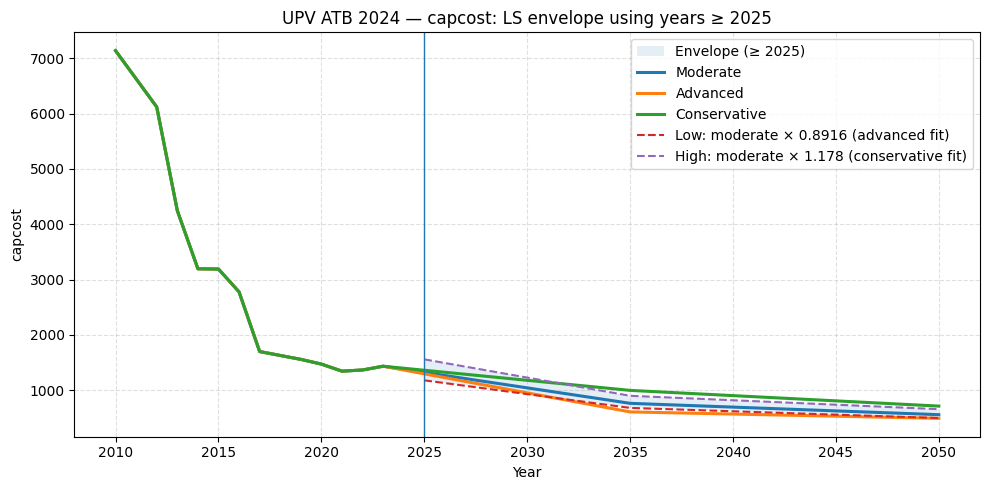

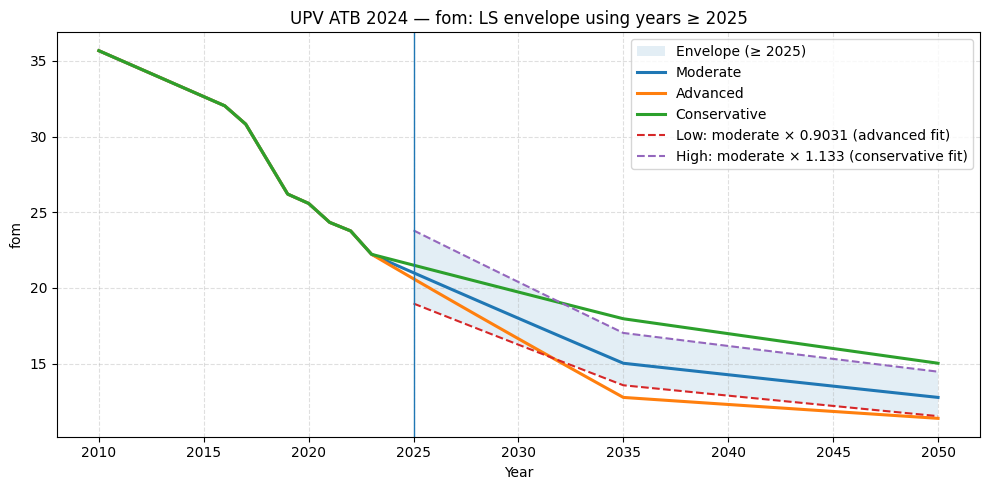

/tmp/ipython-input-2084871928.py:85: RuntimeWarning: All-NaN axis encountered
  low_mult = float(np.nanmin([mA, mC]))
/tmp/ipython-input-2084871928.py:86: RuntimeWarning: All-NaN axis encountered
  high_mult = float(np.nanmax([mA, mC]))


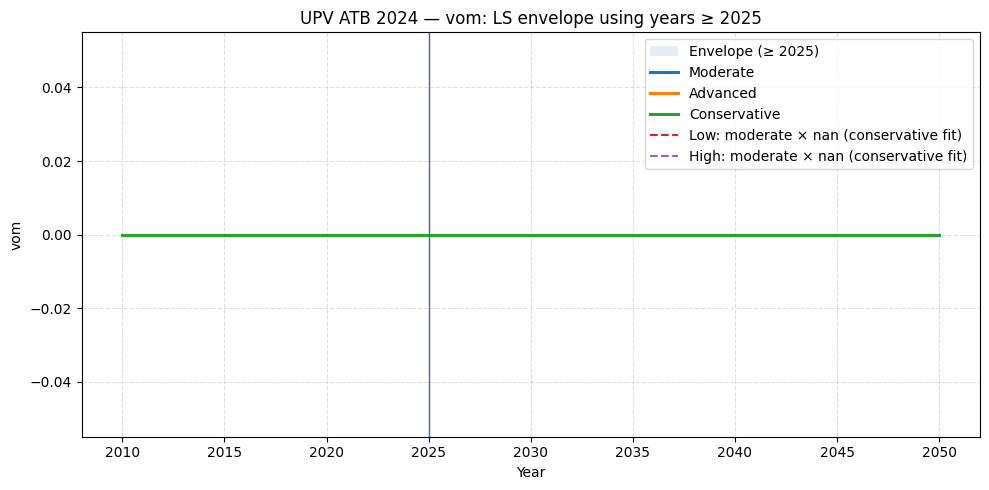

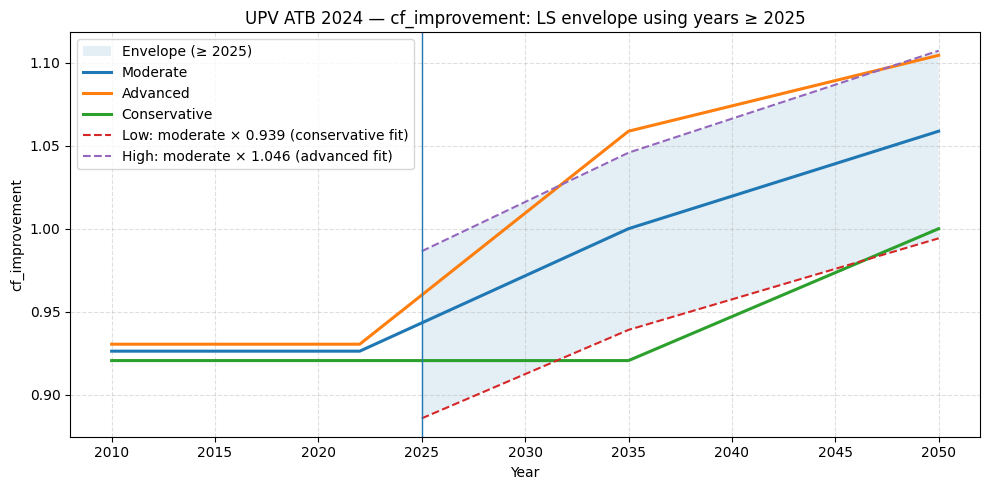

,metric,mA,mC,low_mult,high_mult,low_ref,high_ref,n_years_fit,fit_year_min,fit_year_max
0,capcost,0.891590,1.178078,0.891590,1.178078,advanced,conservative,26,2025,2050
1,fom,0.903122,1.133248,0.903122,1.133248,advanced,conservative,26,2025,2050
2,vom,NaN,NaN,NaN,NaN,conservative,conservative,26,2025,2050
3,cf_improvement,1.045837,0.938978,0.938978,1.045837,conservative,advanced,26,2025,2050


Saved: upv_envelope_multipliers.csv


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# CONFIG (UPV ATB 2024)
# ---------------------------
FILE_URLS = {
    "advanced": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/upv_ATB_2024_advanced.csv#/",
    "moderate": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/upv_ATB_2024_moderate.csv#/",
    "conservative": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/upv_ATB_2024_conservative.csv#/",
}

# Column names in UPV file
COL_YEAR = "t"

# Metrics in the UPV file
METRICS = ["capcost", "fom", "vom", "cf_improvement"]

# Fit multipliers using years >= START_YEAR, then show envelope from START_YEAR onward
START_YEAR = 2025

SAVE_CSV = True
OUT_CSV = "upv_envelope_multipliers.csv"


# ---------------------------
# HELPERS
# ---------------------------
def _clean_url(url: str) -> str:
    """Remove URL fragments like '#/' that can break pd.read_csv over HTTP."""
    return url.split("#", 1)[0]

def load_from_urls(urls: dict) -> pd.DataFrame:
    dfs = []
    for scen, url in urls.items():
        df = pd.read_csv(_clean_url(url))
        df["scenario"] = scen
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)

    # Standardize year
    out[COL_YEAR] = pd.to_numeric(out[COL_YEAR], errors="coerce")
    out = out.dropna(subset=[COL_YEAR]).copy()
    out[COL_YEAR] = out[COL_YEAR].astype(int)

    # Ensure metrics numeric
    for col in METRICS:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    return out.sort_values(["scenario", COL_YEAR]).reset_index(drop=True)

def fit_multiplier_ls(moderate: pd.Series, target: pd.Series) -> float:
    """
    Least-squares multiplier m minimizing || m*moderate - target ||^2
    => m = (moderate·target) / (moderate·moderate)
    """
    m = moderate.values.astype(float)
    y = target.values.astype(float)
    denom = float(np.dot(m, m))
    if denom == 0:
        return np.nan
    return float(np.dot(m, y) / denom)

def envelope_multipliers(df: pd.DataFrame, metric: str, start_year: int = 2025) -> dict:
    piv = (df[[COL_YEAR, "scenario", metric]]
           .dropna(subset=[COL_YEAR, metric])
           .pivot(index=COL_YEAR, columns="scenario", values=metric)
           .sort_index())

    for s in ["moderate", "advanced", "conservative"]:
        if s not in piv.columns:
            raise ValueError(f"Missing scenario '{s}' for metric='{metric}'. Found: {list(piv.columns)}")

    window = piv.loc[piv.index >= start_year].dropna(subset=["moderate", "advanced", "conservative"], how="any")
    if len(window) < 2:
        raise ValueError(f"Not enough overlapping years >= {start_year} for metric='{metric}'.")

    M = window["moderate"]
    mA = fit_multiplier_ls(M, window["advanced"])
    mC = fit_multiplier_ls(M, window["conservative"])

    low_mult = float(np.nanmin([mA, mC]))
    high_mult = float(np.nanmax([mA, mC]))
    low_ref = "advanced" if mA <= mC else "conservative"
    high_ref = "advanced" if mA >= mC else "conservative"

    return {
        "metric": metric,
        "mA": mA,
        "mC": mC,
        "low_mult": low_mult,
        "high_mult": high_mult,
        "low_ref": low_ref,
        "high_ref": high_ref,
        "n_years_fit": int(len(window)),
        "fit_year_min": int(window.index.min()),
        "fit_year_max": int(window.index.max()),
    }

def plot_with_envelope(df: pd.DataFrame, metric: str, start_year: int = 2025):
    info = envelope_multipliers(df, metric, start_year=start_year)

    piv = (df[[COL_YEAR, "scenario", metric]]
           .dropna(subset=[COL_YEAR, metric])
           .pivot(index=COL_YEAR, columns="scenario", values=metric)
           .sort_index())

    years = piv.index
    M_all = piv["moderate"]
    env_low = M_all * info["low_mult"]
    env_high = M_all * info["high_mult"]

    mask = years >= start_year
    yrs_env = years[mask]

    plt.figure(figsize=(10, 5))
    plt.fill_between(
        yrs_env,
        env_low.loc[yrs_env].values,
        env_high.loc[yrs_env].values,
        alpha=0.12,
        label=f"Envelope (≥ {start_year})"
    )

    plt.plot(years, piv["moderate"].values, linewidth=2.2, label="Moderate")
    plt.plot(years, piv["advanced"].values, linewidth=2.2, label="Advanced")
    plt.plot(years, piv["conservative"].values, linewidth=2.2, label="Conservative")

    plt.plot(yrs_env, env_low.loc[yrs_env].values, "--",
             label=f"Low: moderate × {info['low_mult']:.4g} ({info['low_ref']} fit)")
    plt.plot(yrs_env, env_high.loc[yrs_env].values, "--",
             label=f"High: moderate × {info['high_mult']:.4g} ({info['high_ref']} fit)")

    plt.axvline(start_year, linewidth=1)
    plt.title(f"UPV ATB 2024 — {metric}: LS envelope using years ≥ {start_year}")
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return info


# ---------------------------
# RUN
# ---------------------------
df = load_from_urls(FILE_URLS)
print("Rows:", len(df), "| Years:", df[COL_YEAR].min(), "-", df[COL_YEAR].max())

results = []
for m in METRICS:
    results.append(plot_with_envelope(df, m, start_year=START_YEAR))

res = pd.DataFrame(results)
display(res)

if SAVE_CSV:
    res.to_csv(OUT_CSV, index=False)
    print("Saved:", OUT_CSV)


In [2]:
# ---------------------------
# NEW: Sampling + CSV generation
# ---------------------------
def build_base_moderate(df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns the moderate case as a clean (t, capcost, fom, vom, cf_improvement) table.
    """
    base = (df[df["scenario"] == "moderate"][[COL_YEAR] + METRICS]
            .dropna(subset=[COL_YEAR])
            .sort_values(COL_YEAR)
            .reset_index(drop=True))
    # Ensure exact column order like GitHub file
    base = base[[COL_YEAR, "capcost", "fom", "vom", "cf_improvement"]]
    return base

def apply_multipliers_after_year(base: pd.DataFrame, sample_mults: dict, apply_after_year: int) -> pd.DataFrame:
    """
    Applies metric multipliers only for t > apply_after_year.
    """
    out = base.copy()
    mask = out[COL_YEAR].astype(int) > int(apply_after_year)

    for metric, mult in sample_mults.items():
        if metric not in out.columns:
            raise ValueError(f"Metric '{metric}' not in base columns: {list(out.columns)}")
        out.loc[mask, metric] = out.loc[mask, metric] * float(mult)

    return out

def sample_multipliers(envelope_info: dict, rng: np.random.Generator) -> float:
    """
    Uniform sampling within [low_mult, high_mult].
    """
    lo = float(envelope_info["low_mult"])
    hi = float(envelope_info["high_mult"])
    return float(rng.uniform(lo, hi))


In [3]:
from pathlib import Path

# Column names in UPV file
COL_YEAR = "t"

# Metrics in file
METRICS = ["capcost", "fom", "vom", "cf_improvement"]

# Envelope fit start year (same idea as your notebook)
START_YEAR = 2025

# Output envelope multipliers summary
SAVE_CSV = True
OUT_CSV = "upv_envelope_multipliers.csv"

# ---------------------------
# NEW CONFIG (sampling)
# ---------------------------
# Sample only these metrics (vom is constant in UPV)
SAMPLE_METRICS = ["capcost", "fom", "cf_improvement"]

# Apply multipliers only AFTER 2025, i.e., t > 2025
APPLY_AFTER_YEAR = 2025

# How many sampled CSVs to generate
N_SAMPLES = 2

# Reproducibility
RANDOM_SEED = 42

# Where to write sampled CSVs
OUT_DIR = Path("upv_ATB_2024_samples")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Whether to save a summary table of samples
SAVE_SAMPLES_TABLE = True
# Path for the samples summary table
SAMPLES_TABLE_CSV = OUT_DIR / "sampled_multipliers_info.csv"


# ---------------------------
# NEW: Generate sampled UPV CSVs
# ---------------------------
# Build envelope dict for the 3 sampled metrics
env_by_metric = {m: envelope_multipliers(df, m, start_year=START_YEAR) for m in SAMPLE_METRICS}

# Base moderate table (GitHub format)
base = build_base_moderate(df)

rng = np.random.default_rng(RANDOM_SEED)

# "list format" of sampling results
samples_list = []

for k in range(N_SAMPLES):
    sample_mults = {m: sample_multipliers(env_by_metric[m], rng) for m in SAMPLE_METRICS}

    sampled_df = apply_multipliers_after_year(
        base=base,
        sample_mults=sample_mults,
        apply_after_year=APPLY_AFTER_YEAR
    )

    out_path = OUT_DIR / f"upv_ATB_2024_sample_{k:03d}.csv"
    sampled_df.to_csv(out_path, index=False)

    samples_list.append({
        "sample_id": k,
        **{f"{m}_mult": sample_mults[m] for m in SAMPLE_METRICS},
        "apply_after_year": APPLY_AFTER_YEAR,
        "csv_file": str(out_path)
    })

# Show the first few sampled multiplier rows (list format)
print("First 5 samples (multipliers + file):")
for item in samples_list[:5]:
    print(item)

# Optionally save the multipliers table for all samples
if SAVE_SAMPLES_TABLE:
    samples_table = pd.DataFrame(samples_list)
    samples_table.to_csv(SAMPLES_TABLE_CSV, index=False)
    print("Saved:", SAMPLES_TABLE_CSV)


First 5 samples (multipliers + file):
{'sample_id': 0, 'capcost_mult': 1.1133189008988187, 'fom_mult': 1.0041194543262044, 'cf_improvement_mult': 1.0307268584088127, 'apply_after_year': 2025, 'csv_file': 'upv_ATB_2024_samples/upv_ATB_2024_sample_000.csv'}
{'sample_id': 1, 'capcost_mult': 1.0913773343740376, 'fom_mult': 0.9247947413475869, 'cf_improvement_mult': 1.0432320031058384, 'apply_after_year': 2025, 'csv_file': 'upv_ATB_2024_samples/upv_ATB_2024_sample_001.csv'}
Saved: upv_ATB_2024_samples/sampled_multipliers_info.csv


In [4]:
def plot_single_sample(original_df: pd.DataFrame, sampled_df: pd.DataFrame, metric: str, sample_id: int, apply_after_year: int):
    plt.figure(figsize=(10, 5))

    # Plot original scenarios
    piv_orig = (original_df[[COL_YEAR, "scenario", metric]]
                .dropna(subset=[COL_YEAR, metric])
                .pivot(index=COL_YEAR, columns="scenario", values=metric)
                .sort_index())

    plt.plot(piv_orig.index, piv_orig["moderate"].values, linewidth=2.2, label="Original Moderate", color='blue')
    plt.plot(piv_orig.index, piv_orig["advanced"].values, linewidth=1.5, linestyle='--', label="Original Advanced", color='green')
    plt.plot(piv_orig.index, piv_orig["conservative"].values, linewidth=1.5, linestyle='--', label="Original Conservative", color='red')

    # Plot the sampled scenario
    plt.plot(sampled_df[COL_YEAR], sampled_df[metric], linewidth=2.2, label=f"Sampled {metric} (Sample {sample_id:03d})", color='purple', alpha=0.8)

    plt.axvline(apply_after_year, linewidth=1, color='gray', linestyle=':', label=f'Multipliers applied after {apply_after_year}')
    plt.title(f"UPV ATB 2024 — {metric}: Original Scenarios vs. Sample {sample_id:03d}")
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


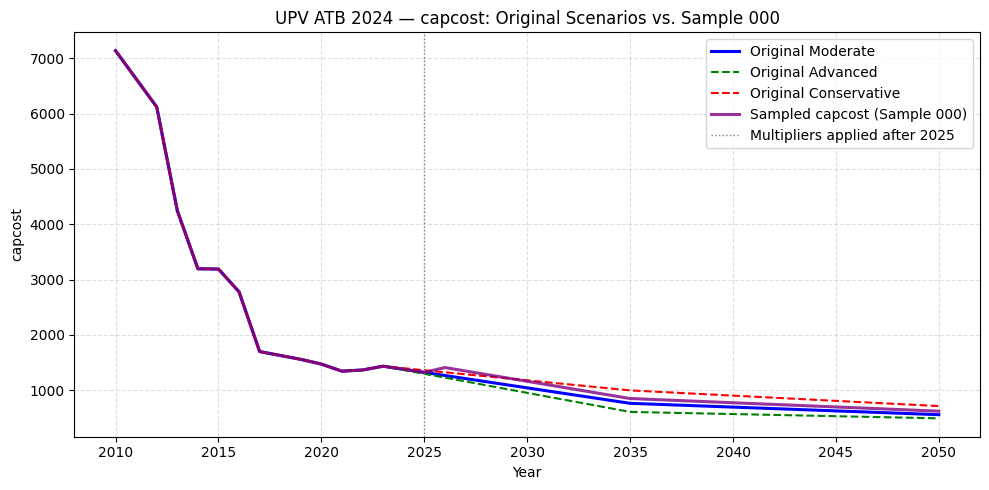

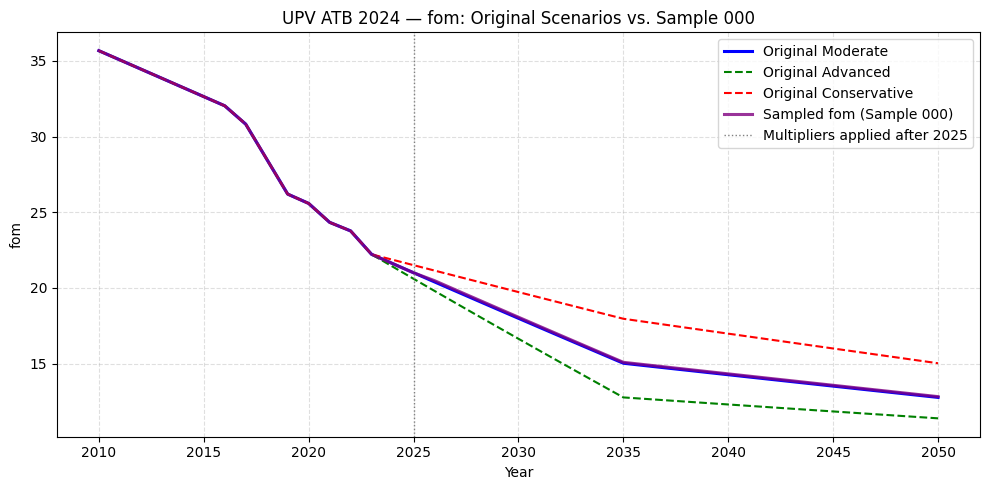

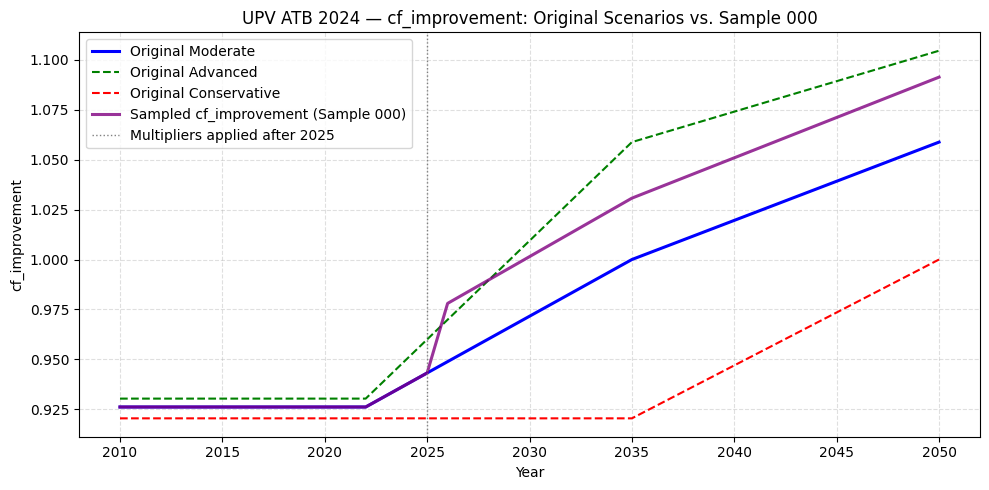

In [5]:
# Select the first sample from samples_list
selected_sample_info = samples_list[0]
sample_id_to_plot = selected_sample_info['sample_id']
sample_csv_path = selected_sample_info['csv_file']

# Load the selected sample CSV
sampled_df_0 = pd.read_csv(sample_csv_path)

# Metrics to plot
metrics_to_plot = ["capcost", "fom", "cf_improvement"]

for metric in metrics_to_plot:
    plot_single_sample(
        original_df=df, # The original DataFrame with all scenarios
        sampled_df=sampled_df_0,
        metric=metric,
        sample_id=sample_id_to_plot,
        apply_after_year=APPLY_AFTER_YEAR
    )


In [6]:
from IPython.display import Markdown, display

# Units of the underlying parameters (multipliers themselves are unitless)
metric_units = {
    "capcost": r"\$/kW",            # UPV cap cost column is $/kW in the plant_characteristics file
    "fom": r"\$/kW-yr",             # fixed O&M is $/(kW-yr)
    "cf_improvement": r"unitless",  # multiplier-like factor
    "vom": r"\$/MWh",
}

# Create the 'bounds' dictionary from 'env_by_metric'
bounds = {}
for metric_name, info_dict in env_by_metric.items():
    bounds[('UPV', metric_name)] = (info_dict['low_mult'], info_dict['high_mult'])

latex_rows = []
for (cls, metric), (low_mult, high_mult) in bounds.items():
    # Prefix UPV before the class label
    parameter = rf"{cls} -- {metric}"
    unit = metric_units.get(metric, "unitless")

    latex_rows.append(
        rf"{parameter} & {high_mult:.4f} & {low_mult:.4f} & {unit} (multiplier) \\"
    )

full_latex_table = rf"""
\begin{{table}}[h!]
\centering
\caption{{Sampled Multiplier Bounds and Parameter Units for UPV ATB 2024}}
\label{{tab:upv_metric_bounds_units}}
\begin{{tabular}}{{l c c c}}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
{chr(10).join(latex_rows)}
\bottomrule
\end{{tabular}}
\end{{table}}
"""

display(Markdown(f"```latex\n{full_latex_table}\n```"))


```latex

\begin{table}[h!]
\centering
\caption{Sampled Multiplier Bounds and Parameter Units for UPV ATB 2024}
\label{tab:upv_metric_bounds_units}
\begin{tabular}{l c c c}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
UPV -- capcost & 1.1781 & 0.8916 & \$/kW (multiplier) \\
UPV -- fom & 1.1332 & 0.9031 & \$/kW-yr (multiplier) \\
UPV -- cf_improvement & 1.0458 & 0.9390 & unitless (multiplier) \\
\bottomrule
\end{tabular}
\end{table}

```

In [7]:
import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# UPV ATB 2024 — Morris-based CSV generation
#   - Base file columns EXACTLY like NREL moderate
#   - Applies multipliers for years >= APPLY_FROM_YEAR (or >)
#   - One output CSV per Morris row (e.g., 200 files)
#   - Output columns/order match the NREL base file exactly
# ============================================================

# -----------------------------
# CONFIG (edit only if needed)
# -----------------------------
APPLY_FROM_YEAR = 2025          # apply for t >= 2025
USE_STRICT_GT = False          # True => apply for t > 2025 (i.e., 2026+)

MORRIS_DESIGN_URL = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_design_r5_p6.csv#/"
FACTOR_MAP_URL    = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_factor_map.csv#/"

# Recommended: load UPV moderate directly from NREL GitHub (ensures exact format)
UPV_MODERATE_URL  = "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/upv_ATB_2024_moderate.csv"

OUT_DIR = Path("upv_ATB_2024_morris_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_MANIFEST = True
MANIFEST_CSV = OUT_DIR / "upv_ATB_2024_morris_manifest.csv"

# Metrics in UPV file (expected)
ALL_METRICS = ["capcost", "fom", "vom", "cf_improvement"]

# Usually VOM is constant in UPV; we typically do NOT sample it
SAMPLED_METRICS = ["capcost", "fom", "cf_improvement"]

# -----------------------------
# 1) Load Morris design + factor map
# -----------------------------
design = pd.read_csv(MORRIS_DESIGN_URL)
factor_map = pd.read_csv(FACTOR_MAP_URL)

# -----------------------------
# 2) Load the UPV moderate base EXACTLY like NREL
# -----------------------------
base = pd.read_csv(UPV_MODERATE_URL)

# Validate base columns/order
expected_cols = ["t"] + ALL_METRICS
if list(base.columns) != expected_cols:
    raise ValueError(
        "Base UPV moderate file does not match expected columns/order.\n"
        f"Expected: {expected_cols}\n"
        f"Found:    {list(base.columns)}\n"
        "Fix: point UPV_MODERATE_URL to the exact NREL file you intend to use."
    )

base["t"] = base["t"].astype(int)
BASE_COL_ORDER = list(base.columns)

# -----------------------------
# 3) Resolve which Morris design column corresponds to each UPV metric
# -----------------------------
def _find_col_case_insensitive(df: pd.DataFrame, name: str):
    m = {c.lower(): c for c in df.columns}
    return m.get(name.lower(), None)

def resolve_design_col_for(metric: str) -> str:
    """
    Tries to find the design column for UPV metric using:
      - direct names like "UPV__capcost" / "UPV--capcost" / "UPV_capcost"
      - or via factor_map, if it contains a parameter string like "UPV -- capcost"
        and a factor id that appears as a design column.
    """
    # (A) Direct common patterns
    direct_candidates = [
        f"UPV__{metric}",
        f"UPV--{metric}",
        f"UPV_{metric}",
        f"UPV {metric}",
        f"upv__{metric}",
        f"upv--{metric}",
        f"upv_{metric}",
        f"upv {metric}",
    ]
    for cand in direct_candidates:
        c = _find_col_case_insensitive(design, cand)
        if c is not None:
            return c

    # (B) Factor-map based
    param_col = None
    for pc in ["parameter", "Parameter", "name", "Name", "desc", "description"]:
        if pc in factor_map.columns:
            param_col = pc
            break

    factor_col = None
    for fc in ["factor", "Factor", "id", "ID"]:
        if fc in factor_map.columns:
            factor_col = fc
            break

    if param_col is not None and factor_col is not None:
        mask = (
            factor_map[param_col].astype(str).str.contains("UPV", case=False, na=False) &
            factor_map[param_col].astype(str).str.contains(metric, case=False, na=False)
        )
        hits = factor_map.loc[mask]
        if len(hits) > 0:
            f = str(hits.iloc[0][factor_col])
            c = _find_col_case_insensitive(design, f)
            if c is not None:
                return c
            if f in design.columns:
                return f

    raise ValueError(
        f"Could not resolve Morris design column for UPV metric '{metric}'.\n"
        "Fix options:\n"
        "  - Rename your morris_design columns to UPV__capcost, UPV__fom, UPV__cf_improvement, OR\n"
        "  - Ensure morris_factor_map has a 'parameter' column containing 'UPV' and the metric name,\n"
        "    plus a 'factor' column whose IDs match columns in morris_design.\n"
        f"Design columns preview: {list(design.columns)[:30]}"
    )

design_cols = {m: resolve_design_col_for(m) for m in SAMPLED_METRICS}
print("Resolved Morris design columns:")
for k, v in design_cols.items():
    print(f"  {k} -> {v}")

# -----------------------------
# 4) Apply multipliers to base and write 1 CSV per Morris row
# -----------------------------
def apply_upv_multipliers(base_df: pd.DataFrame, mults: dict, apply_from_year: int, strict_gt: bool) -> pd.DataFrame:
    out = base_df.copy()
    if strict_gt:
        mask = out["t"].astype(int) > int(apply_from_year)
    else:
        mask = out["t"].astype(int) >= int(apply_from_year)

    for metric, mult in mults.items():
        out.loc[mask, metric] = out.loc[mask, metric].astype(float) * float(mult)

    # enforce EXACT same column order
    return out[BASE_COL_ORDER]

manifest = []
for ridx, row in design.reset_index(drop=True).iterrows():
    # pull multipliers for sampled metrics from the design row
    mults = {m: float(row[design_cols[m]]) for m in SAMPLED_METRICS}

    df_out = apply_upv_multipliers(base, mults, APPLY_FROM_YEAR, USE_STRICT_GT)

    fname = f"upv_ATB_2024_morris_{ridx:03d}.csv"
    fpath = OUT_DIR / fname
    df_out.to_csv(fpath, index=False, float_format="%.6f")

    rec = {
        "morris_row": ridx,
        "file": fname,
        "apply_rule": (f"t > {APPLY_FROM_YEAR}" if USE_STRICT_GT else f"t >= {APPLY_FROM_YEAR}")
    }
    for m in SAMPLED_METRICS:
        rec[f"UPV__{m}_mult"] = mults[m]
    manifest.append(rec)

manifest_df = pd.DataFrame(manifest)
if SAVE_MANIFEST:
    manifest_df.to_csv(MANIFEST_CSV, index=False)

print(f"\nDone. Wrote {len(manifest_df)} UPV Morris files to:\n  {OUT_DIR.resolve()}")
print(f"Manifest:\n  {MANIFEST_CSV}")

# -----------------------------
# 5) Safety check: output file columns EXACTLY match NREL moderate
# -----------------------------
def validate_file(fp: Path, expected_cols: list[str]):
    tmp = pd.read_csv(fp)
    if list(tmp.columns) != expected_cols:
        raise ValueError(
            f"Column mismatch in {fp.name}\n"
            f"Expected: {expected_cols}\n"
            f"Found:    {list(tmp.columns)}"
        )

validate_file(OUT_DIR / "upv_ATB_2024_morris_000.csv", expected_cols)
validate_file(OUT_DIR / f"upv_ATB_2024_morris_{len(manifest_df)-1:03d}.csv", expected_cols)
print("Validation passed: output columns/order match NREL moderate exactly.")

# Optional preview
display(pd.read_csv(OUT_DIR / "upv_ATB_2024_morris_000.csv").head(15))


Resolved Morris design columns:
  capcost -> upv_capcost
  fom -> upv_fom
  cf_improvement -> upv_cf_improvement

Done. Wrote 200 UPV Morris files to:
  /content/upv_ATB_2024_morris_outputs
Manifest:
  upv_ATB_2024_morris_outputs/upv_ATB_2024_morris_manifest.csv
Validation passed: output columns/order match NREL moderate exactly.


,t,capcost,fom,vom,cf_improvement
0,2010,7134.473220,35.672366,0,0.926147
1,2011,6626.226717,35.065668,0,0.926147
2,2012,6117.980210,34.458970,0,0.926147
3,2013,4246.109494,33.852272,0,0.926147
4,2014,3195.163027,33.245574,0,0.926147
5,2015,3190.130650,32.638876,0,0.926147
6,2016,2777.886445,32.032178,0,0.926147
7,2017,1699.682398,30.818781,0,0.926147
8,2018,1629.132468,28.509015,0,0.926147
9,2019,1558.582537,26.199249,0,0.926147


In [8]:
from pathlib import Path
import shutil

OUT_DIR = Path("upv_ATB_2024_morris_outputs")  # <- must match your script
zip_name = "upv_ATB_2024_morris_outputs"

# create gas_ccs_ATB_2024_morris_outputs.zip
shutil.make_archive(zip_name, "zip", OUT_DIR)

print("Created:", f"{zip_name}.zip")

Created: upv_ATB_2024_morris_outputs.zip
